# Analysis — Same Particle - Error Bar

Aqui analisamos mesma partícula, para 3 valores de potências (100mA, 150mA e 200mA) para 3 frequências diferenstes. Para cada (potência, freq) realizamos o experimento 20 vezes.

In [1]:
import matplotlib.pyplot as plt
import os
from scipy.optimize import curve_fit
import numpy as np
np.seterr('warn')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## Configuração
Edite apenas esta célula para adicionar/remover partículas ou frequências.

In [2]:
data_path = "./22-04-26/lum_laser750mA_counts4k"

In [3]:
filenames_all = []

for root, dirs, files in os.walk(data_path):
    # print(root)
    for name in files:
        # os.path.join combina o diretório atual (root) com o nome do arquivo
        # print(name)
        full_path = os.path.join(root, name)
        filenames_all.append(full_path.replace("\\", "/"))

In [4]:
def extract_info(path: str):
  freq = int(path.split("_fg")[1].split("Hz")[0])
  amp = float(path.split("Hz_")[1].split("V_")[0])
  offset = float(path.split("V_")[1].split("offs")[0])

  return {
      "freq": freq,
      "amp": amp,
      "offset": offset,
      "data": np.loadtxt(path),
  }

In [5]:
exc_data = [extract_info(laser_data_path) for laser_data_path in filenames_all if ("/laser/" in laser_data_path) and ("step" in laser_data_path)]

In [6]:
exp_list = []
for exp in range(14):
    exp_list.append(
        [extract_info(lum_data_path) for lum_data_path in filenames_all if (f"/exp{exp+1}/" in lum_data_path) and ("step" in lum_data_path)]
    )

## Funções auxiliares

In [7]:
def shorten_points(data, num_points_off=10):
    """Remove os primeiros e últimos `num_points_off` pontos. Aceita shape (2, N)."""
    
    if len(data) > 200:
        data = data[:200]

    xs, ys = data[:,0], data[:,1]
    return xs[num_points_off:-num_points_off], ys[num_points_off:-num_points_off]


def make_fitting_func(omega):
    """Retorna a função seno parametrizada para a frequência angular `omega`."""
    def fitting_func(t, A, A0, phi):
        return A0 + np.abs(A) * np.sin(omega * t + phi)
    return fitting_func


def fit_curve(curve, fitting_func, p0=None):
    """Ajusta `fitting_func` aos dados de `curve` (array Nx2)."""
    
    if len(curve) > 200:
        curve = curve[:200]
    
    xs, ys = shorten_points(curve)
    popt, pcov = curve_fit(fitting_func, xs, ys, p0=p0)
    return xs, popt, pcov


def adj_omega(x):
    """Converte omega (rad/µs) para frequência em Hz."""
    return x * 1e6 / (2 * np.pi)


def adj_ph(x, correct=False):
    """Ajusta a fase: se `correct=True`, mapeia valores de fase para o intervalo [-180, 180]."""
    # if correct:
        # return np.where(x > 180, x - 360, -x)
    return (360 - x)

def inverse_variance(variance_list: list):
    return 1/sum([1/variance for variance in variance_list])

def sort_experiments_by_freq(exp_list: list):
    """Return a new list of experiments sorted by their 'freq' key."""
    return sorted(exp_list, key=lambda exp: exp['freq'])    

## Análise — loop sobre N partículas


Processing Experiment 1


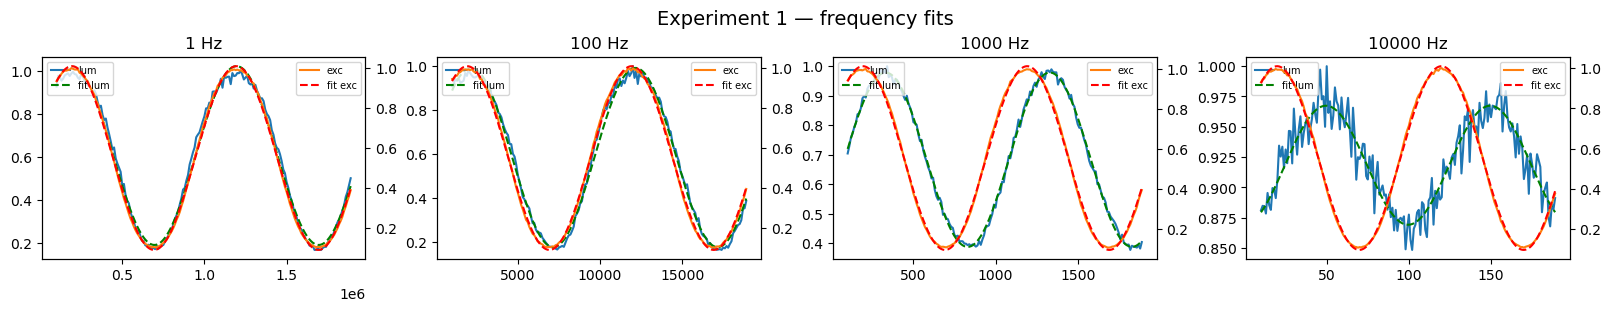


Processing Experiment 2


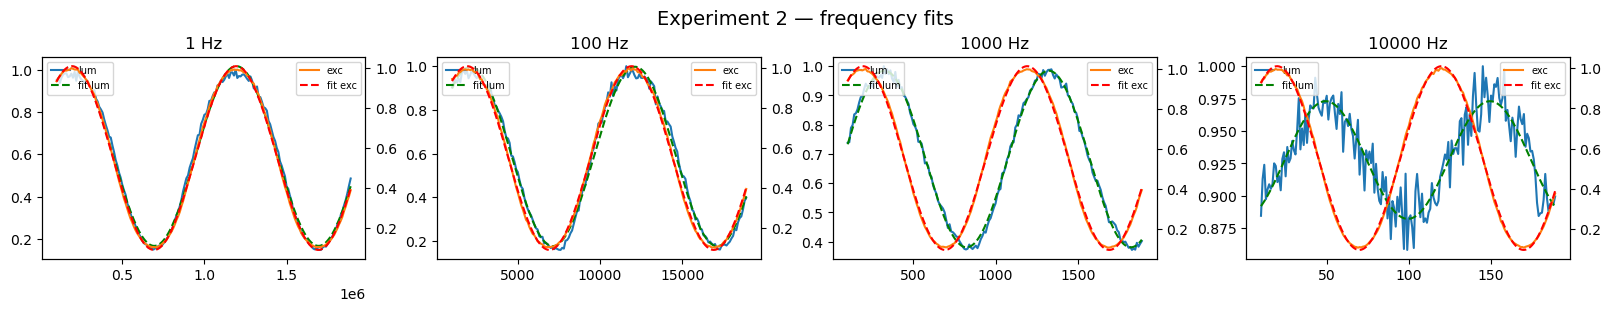


Processing Experiment 3


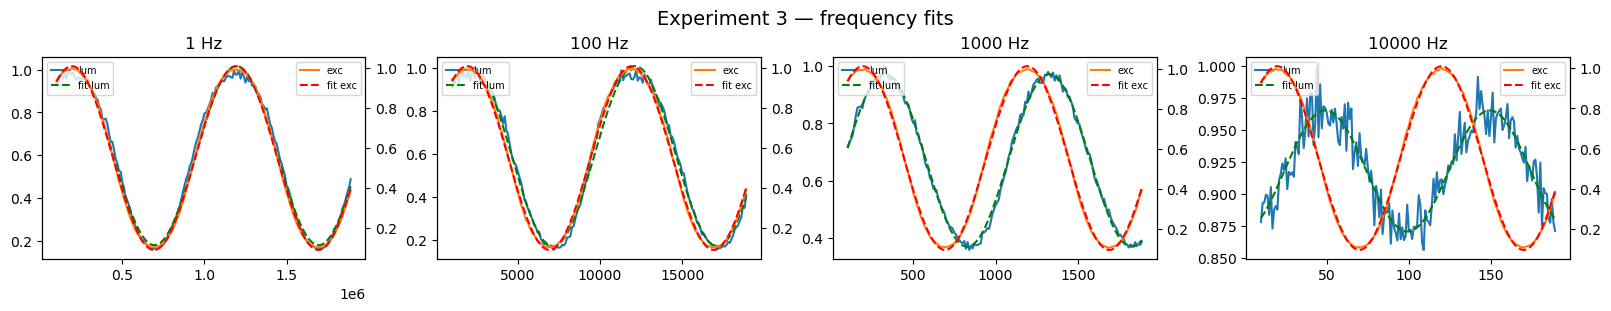


Processing Experiment 4


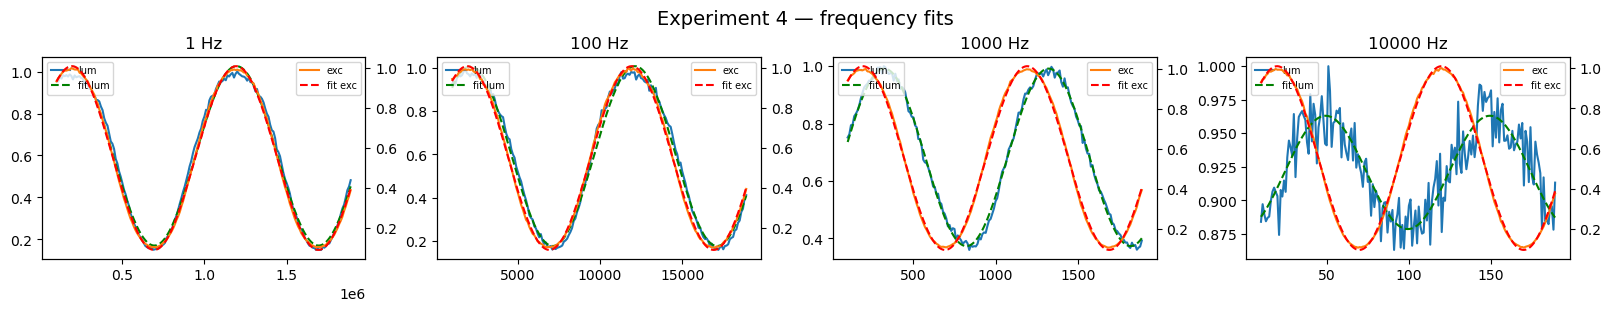


Processing Experiment 5


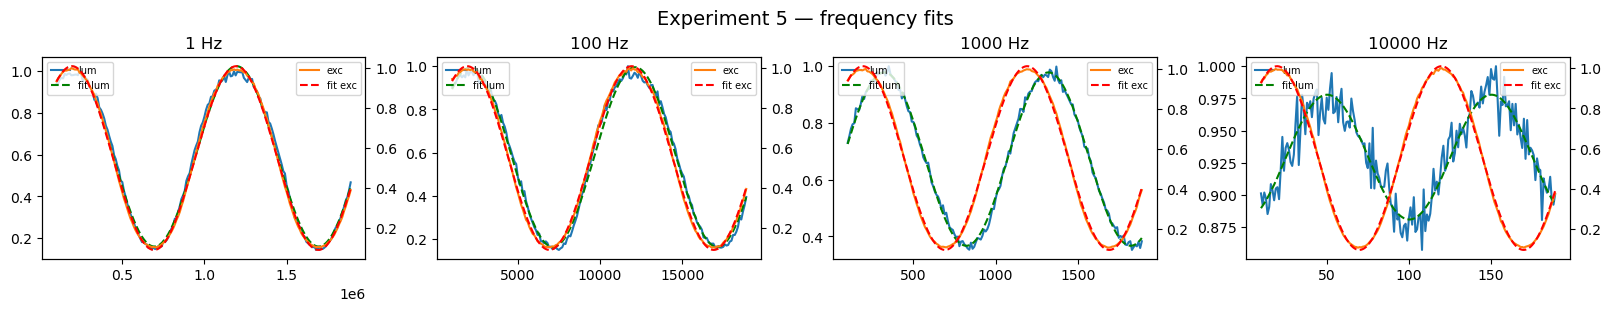


Processing Experiment 6


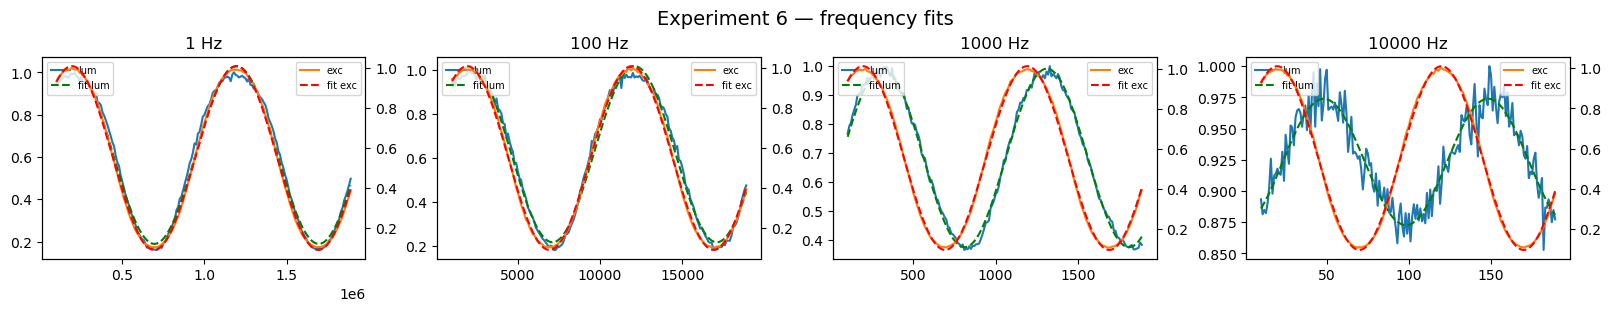


Processing Experiment 7


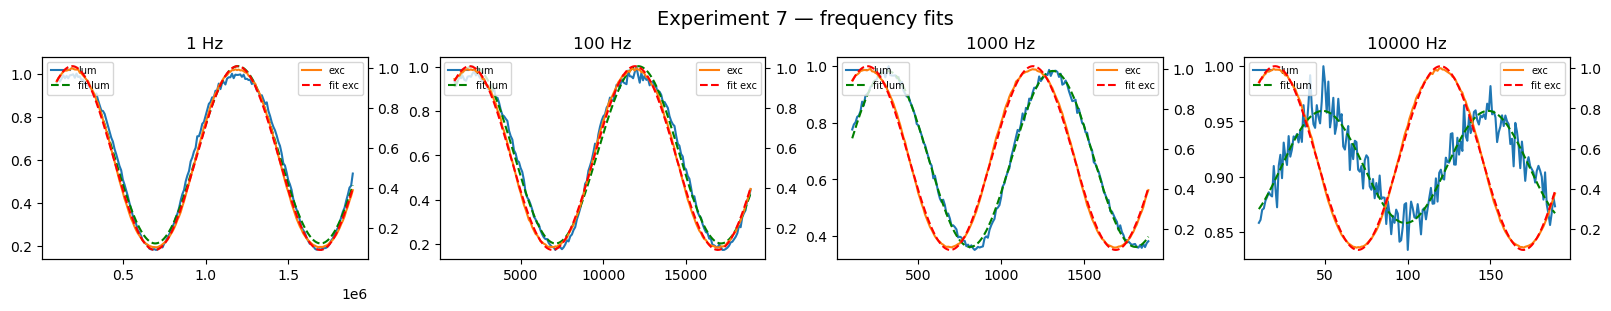


Processing Experiment 8


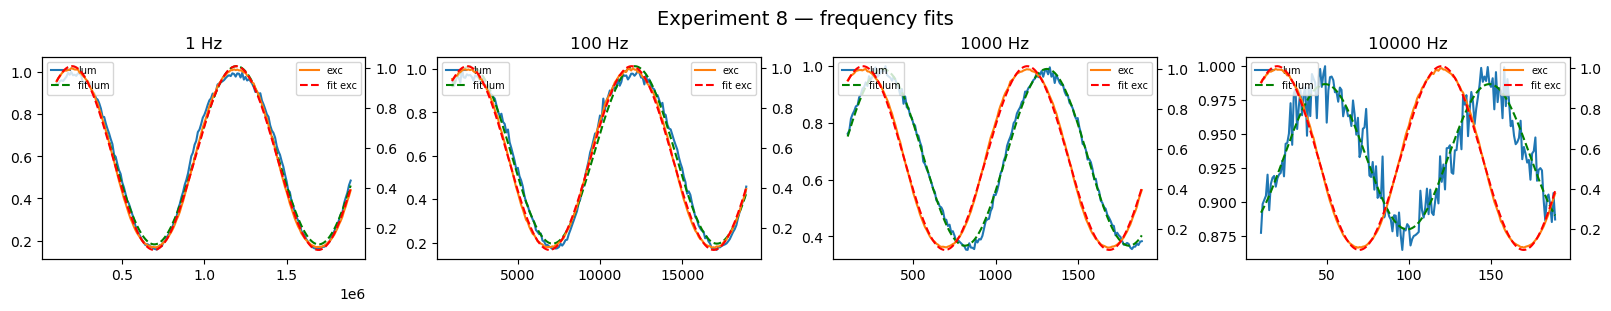


Processing Experiment 9


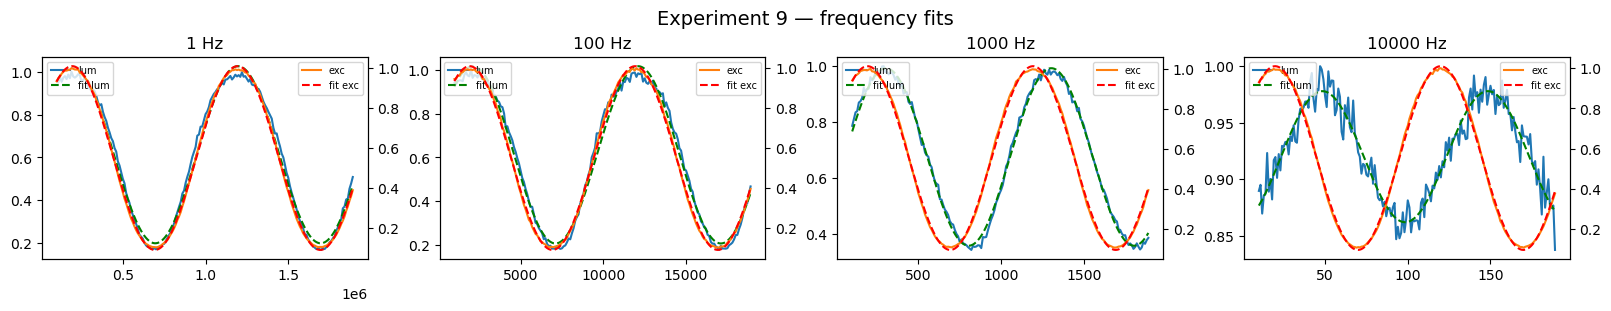


Processing Experiment 10


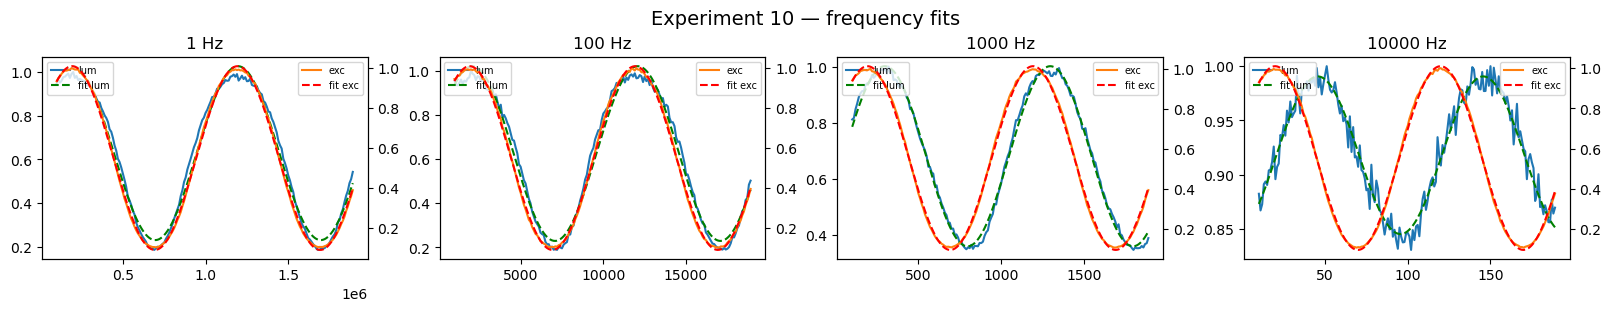


Processing Experiment 11


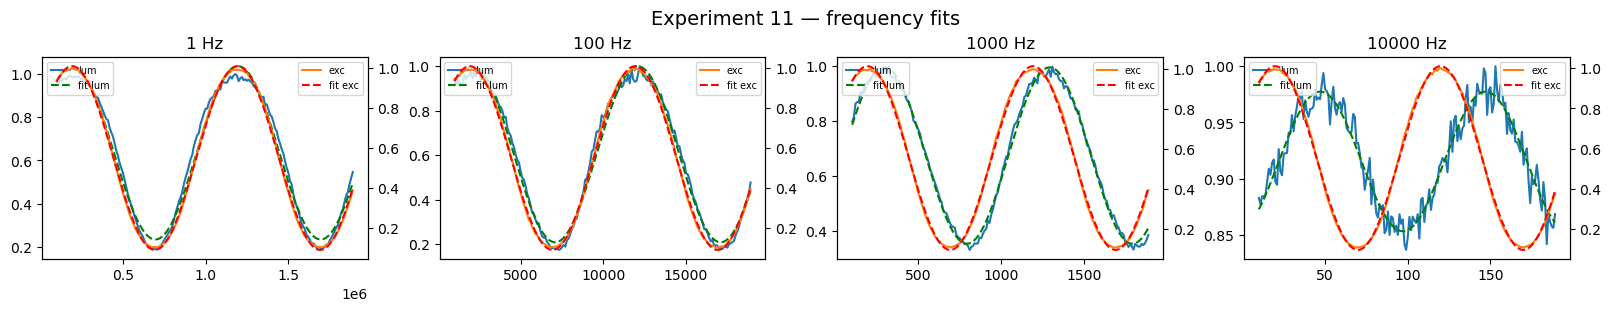


Processing Experiment 12


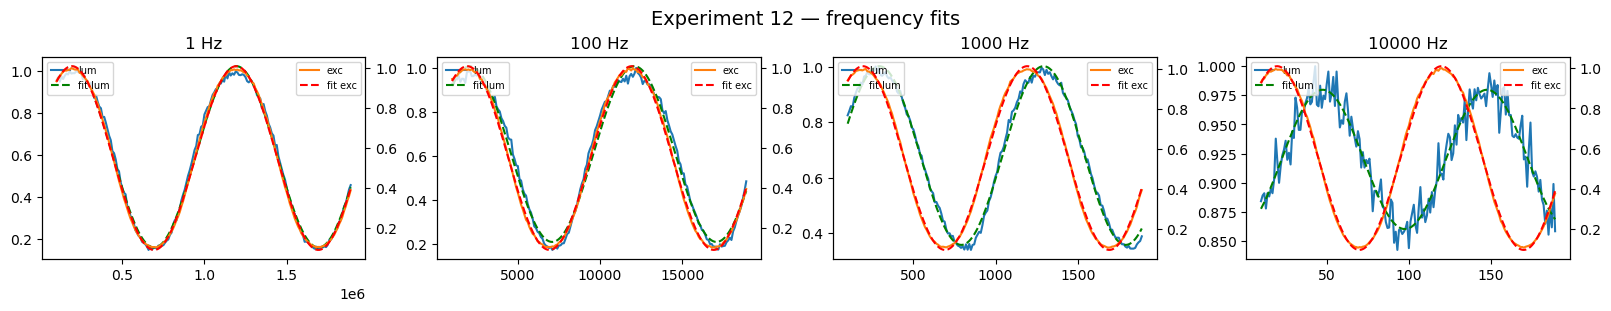


Processing Experiment 13


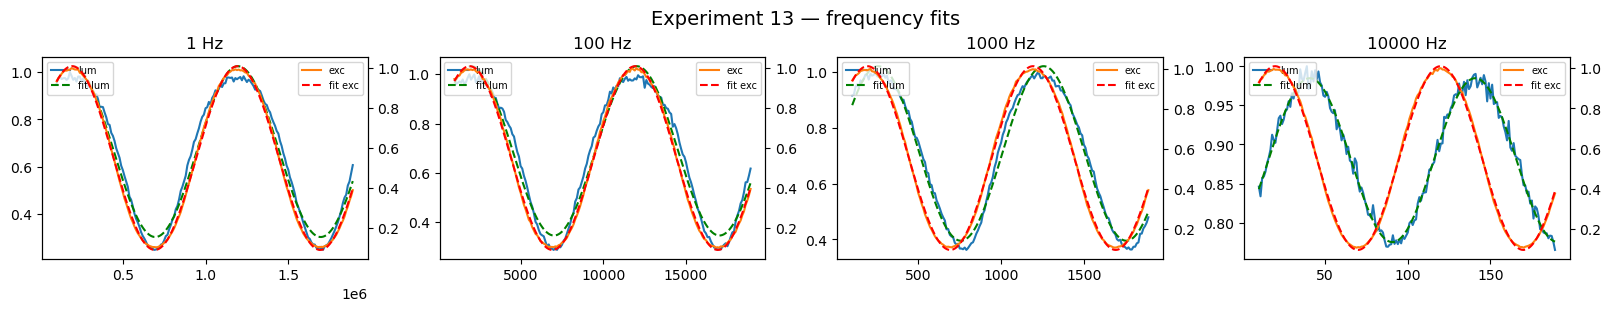


Processing Experiment 14


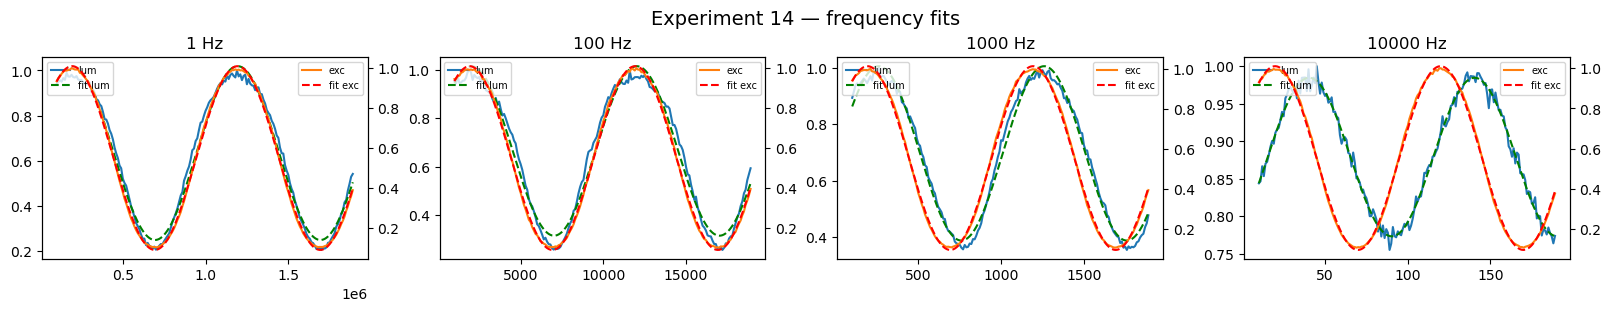

In [8]:
# Pré-carrega os dados de excitação uma única vez (são os mesmos para todas as partículas)
# exc_data = {freq: np.loadtxt(f"{data_path_exc}/{freq}hzAPDA.txt") for freq in freq_list}
exc_data = sort_experiments_by_freq(exc_data)

cols = 4
rows = len(exc_data) // cols + (1 if len(exc_data) % cols > 0 else 0)

results = []   # armazena resultados de cada partícula
# error_bars = [] # armazena erros para cada partícula
phase_diffs = []

for exp_idx, exp_data in enumerate(exp_list):
    # freq, freq_path = freq_dic["freq"], freq_dic["path"]k
    exp_label = f"Experiment {exp_idx+1}"
    # correct = False # adj_phase_correction[f_idx] if p_idx < len(adj_phase_correction) else False
    

    print(f"\n{'='*50}")
    print(f"Processing Experiment {exp_idx+1}")
    print(f"{'='*50}")

    omegas      = []
    pcov_lum_list = []
    pcov_exc_list = []

    # ---- Subplots de verificação visual ----
    fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), constrained_layout=True)
    fig.suptitle(f"{exp_label} — frequency fits", fontsize=14)

    for index, freq_data in enumerate(exp_data):
        freq = freq_data["freq"]
        # print(f"\nProcessing frequency {freq} (type{type(freq)}) Hz for {exp_label}")
        # i, j = divmod(index, cols)
        # print(f"(i, j) = ({i}, {j}) for freq {freq} Hz")
        omega = 2 * np.pi * freq*1e-6  # Convertendo freq de Hz para rad/µs
        omegas.append(omega)

        fitting_func = make_fitting_func(omega)
        p0 = [1587.92259477, 2275.5144266, -81.46603027] if (freq == 100 and (exp_idx == 11 or exp_idx == 13)) else None #freq_dic["fitting_problems"].get(index, None)

        lum_curve = freq_data["data"]
        exc_curve = exc_data[index]["data"] if exc_data[index]["freq"] == freq else None

        # print(f"Excitation curve for {freq} Hz: {exc_curve}")
        xs_exc, popt_exc, pcov_exc = fit_curve(exc_curve, fitting_func, p0=p0)
        xs_lum, popt_lum, pcov_lum = fit_curve(lum_curve, fitting_func, p0=p0)
        pcov_exc_list.append(np.diag(pcov_exc)[2])
        pcov_lum_list.append(np.diag(pcov_lum)[2])
        

        ph_exc = popt_exc[2]
        ph_lum = popt_lum[2]
        phase_diffs.append({
            "exp": exp_idx+1,
            "freq": freq,
            "pd": 360 - (np.degrees(ph_lum - ph_exc) % 360),
            })

        # Plot normalizado
        x_exc, y_exc = shorten_points(exc_curve)
        x_lum, y_lum = shorten_points(lum_curve)
   
        
        ax = axs[index]
        ax.plot(x_lum, y_lum / np.max(y_lum), label="lum")
        ax.plot(xs_lum, fitting_func(xs_lum, *popt_lum) / np.max(y_lum), "g--", label="fit lum")
        ax.set_title(f"{freq} Hz")
        ax.legend(loc="upper left", fontsize=7)

        ax2 = ax.twinx()
        ax2.plot(x_exc, y_exc / np.max(y_exc), color="tab:orange", label="exc")
        ax2.plot(xs_exc, fitting_func(xs_exc, *popt_exc) / np.max(y_exc), "r--", label="fit exc")
        ax2.legend(loc="upper right", fontsize=7)

    plt.show()


## Comparison

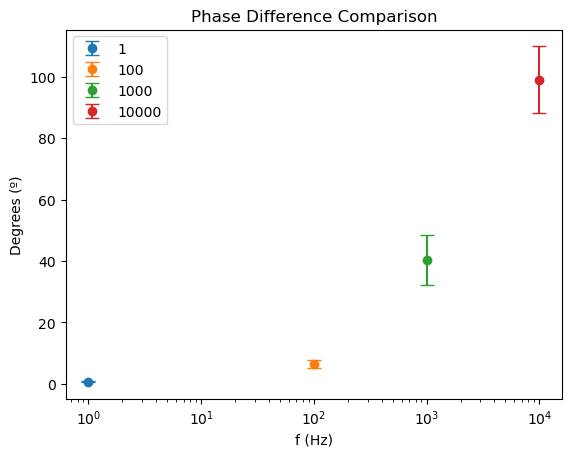

In [9]:
freq_list = sorted(list(set(
    [pd["freq"] for pd in phase_diffs]
)))

error_bars= []

for freq in freq_list:
    pd_for_freq = [pd["pd"] for pd in phase_diffs if pd["freq"] == freq]
    mean_pd = np.mean(pd_for_freq)
    std_pd = np.std(pd_for_freq)

    # print(f"Phase differences for {freq} Hz: {len(pd_for_freq)}")

    error_bars.append({
        "freq": freq,
        "mean": mean_pd,
        "std": std_pd,
        })

for idx, r in enumerate(error_bars):
    # color = colors[idx % len(colors)]
    plt.errorbar(
        freq_list[idx],
        error_bars[idx]["mean"],
        yerr=error_bars[idx]["std"],
        label=error_bars[idx]["freq"],
        fmt='o',
        capsize=5,
        # color=color,
    )

plt.xscale("log")
plt.title("Phase Difference Comparison")
plt.ylabel("Degrees (º)")
plt.xlabel("f (Hz)")
plt.legend()
plt.show()

In [10]:
error_bars

[{'freq': 1,
  'mean': np.float64(0.7210498581064095),
  'std': np.float64(0.22372415256842446)},
 {'freq': 100,
  'mean': np.float64(6.494559960081465),
  'std': np.float64(1.408443228316822)},
 {'freq': 1000,
  'mean': np.float64(40.353166100074375),
  'std': np.float64(8.034176501000964)},
 {'freq': 10000,
  'mean': np.float64(99.06775536505486),
  'std': np.float64(10.809057516900852)}]

# Junk